# Distribution of device usage among users

C:\Users\SajayN\AppData\Local\Temp\ipykernel_63596\569543214.py:26: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  with engine.connect() as con:


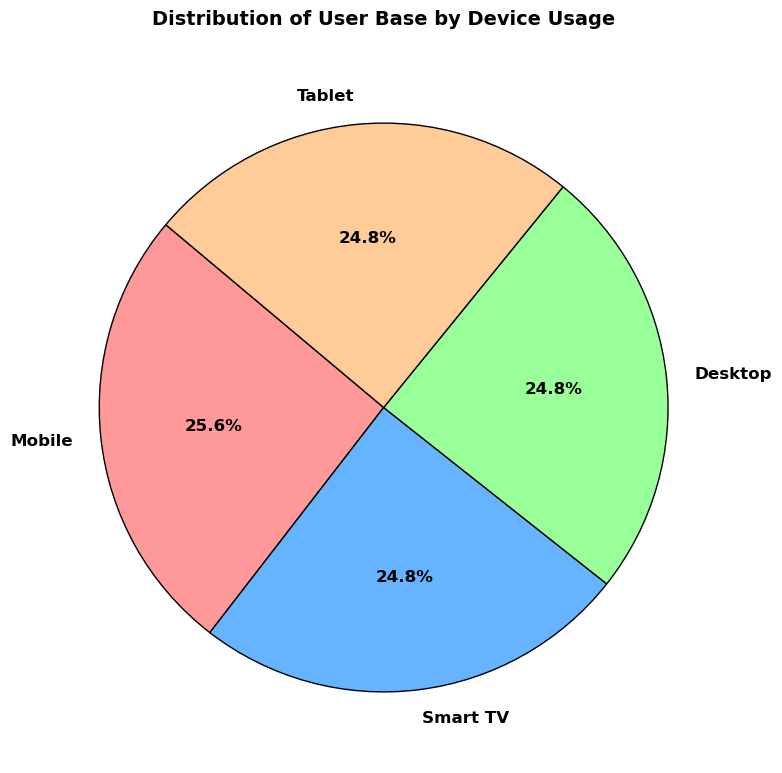

In [2]:
import pandas as pd
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

# 1. Setup your database engine
connection_string = (
    "mssql+pyodbc://@./DA07_movieDB?"
    "driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes"
)
engine = create_engine(connection_string)

# 2. SQL Query to get total users grouped by device
query = """
SELECT 
    device,
    COUNT(user_id) AS total_users
FROM [dbo].[users]
GROUP BY 
    device
ORDER BY 
    total_users DESC;
"""

try:
    # 3. Pull the data into a DataFrame
    with engine.connect() as con:
        df_device = pd.read_sql(query, con)
    
    # 4. Initialize the plot window
    plt.figure(figsize=(8, 8))
    
    # 5. Build the pie chart
    # autopct='%1.1f%%' automatically calculates and adds the percentage labels onto the slices
    plt.pie(
        df_device['total_users'], 
        labels=df_device['device'], 
        autopct='%1.1f%%', 
        startangle=140,              # Rotates the starting point for a cleaner split
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'], # A nice, modern color palette
        textprops={'fontweight': 'bold', 'fontsize': 12}, # Makes labels clean and readable
        wedgeprops={'edgecolor': 'black', 'linewidth': 1} # Adds distinct borders between slices
    )
    
    # 6. Customize the chart layout
    plt.title('Distribution of User Base by Device Usage', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"An error occurred: {e}")

# 

C:\Users\SajayN\AppData\Local\Temp\ipykernel_63596\278516886.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, con)


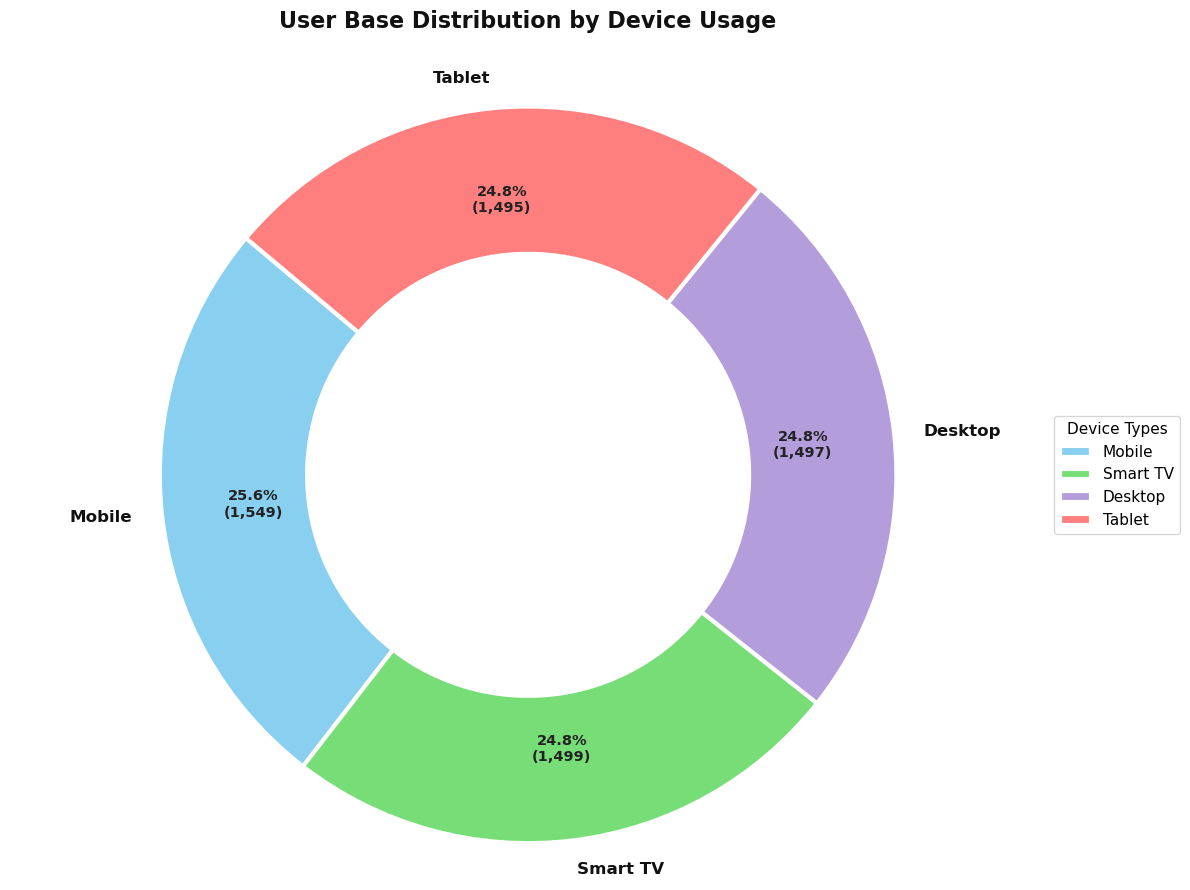

In [4]:
import pyodbc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Connect to your SQL Server
con = pyodbc.connect(
    DRIVER='{ODBC Driver 17 for SQL Server}', 
    SERVER='.', 
    DATABASE='DA07_movieDB', 
    Trusted_Connection='Yes', 
    autocommit=True
)

# 2. SQL Query: Fetching user distribution by device (Fixed spacing syntax)
query = """
SELECT 
    device,
    COUNT(user_id) AS total_users
FROM [dbo].[Users]
GROUP BY 
    device
ORDER BY 
    total_users DESC;
"""

df = pd.read_sql(query, con)
con.close()

# 3. Define the presentation palette for your devices
device_colors = ['#89CFF0', '#77DD77', '#B39DDB', '#FF7F7F', '#FFD700', '#E6A8D7']
colors = device_colors[:len(df)]

# 4. Setup the Interface Canvas with a Clean White Background
plt.figure(figsize=(12, 9), facecolor='#FFFFFF')
ax = plt.gca()

# 5. Advanced Feature: Custom function to show BOTH % and absolute counts together
def label_format(pct, all_vals):
    absolute = int(round(pct/100.0 * sum(all_vals)))
    return f"{pct:.1f}%\n({absolute:,})"

# 6. Generate the Pie (Donut) Chart using your explicit 'device' column
wedges, texts, autotexts = ax.pie(
    df['total_users'], 
    labels=df['device'], 
    autopct=lambda pct: label_format(pct, df['total_users']),
    startangle=140, 
    colors=colors,
    pctdistance=0.75,     # Inner metrics position
    labeldistance=1.08,   # Outer category label position
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#111111'}, 
    wedgeprops={
        'width': 0.4,          # Creates the modern donut center cutout
        'edgecolor': '#FFFFFF', # Clean white dividing borders
        'linewidth': 3
    }
)

# 7. Style the inner metric fonts for sharp contrast
for autotext in autotexts:
    autotext.set_color('#222222')
    autotext.set_fontsize(10.5)
    autotext.set_fontweight('bold')

# 8. Title and Layout Polish
plt.title('User Base Distribution by Device Usage', 
          fontsize=16, fontweight='bold', color='#111111', pad=30)

plt.legend(
    wedges, 
    df['device'],
    title="Device Types",
    title_fontsize=11,
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
    fontsize=11
)

plt.axis('equal')  # Forces perfectly round proportions
plt.tight_layout()
plt.show()